In [12]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append('..')
from src.env_setup import init_analysis_env; init_analysis_env()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
🚀 Analysis environment initialized: pd, np, plt, sns, load_local_data are ready.


In [15]:
df = load_local_data("Stock Screener Data*.csv*", na_values=['-'], dtype={'Code': str})
df.head()

Loading: /home/mrsmmori/notebooks/Win_Downloads/Stock Screener Data 7 Jun 11-8-22.csv.csv


,Trading Name,Code,Last Price,ROE %,Mkt Cap ($M),Tot. Rev ($M),P/E,Yield (%),Sector,GTI Score,4-wk %Pr. Chg.,13-wk %Pr. Chg.,26-wk %Pr. Chg.,52-wk %Pr. Chg.,Net Profit,Price/CF,Debt/Equity,1-yr %Rev. Chg.,Price/Book Value
0,Tai Sin Electric,500,0.545,12.09,SGD 250.843,SGD 527.837,14.30,4.31,Industrials,78.0,-5.22,5.24,-5.56,38.66,0.05,NaN,0.04,19.98,1.12
1,HS Optimus,504,0.007,5.73,SGD 37.664,SGD 13.551,13.73,NaN,Consumer Cyclical,67.0,0.00,133.33,250.00,250.00,0.20,74.07,0.01,-6.18,0.77
2,AsiaMedic,505,0.023,13.34,SGD 26.4,SGD 35.221,13.14,NaN,Healthcare,66.0,0.00,21.05,21.05,91.67,0.03,6.85,0.96,21.81,1.64
3,Fuji Offset,508,0.730,2.33,SGD 43.736,SGD 3.274,48.34,0.68,Industrials,70.0,28.95,5.76,36.11,-10.91,0.28,357.14,0.00,-9.76,1.14
4,DISA,532,0.001,-137.72,SGD 14.09,SGD 2.667,NaN,NaN,Technology,34.0,0.00,0.00,0.00,0.00,-0.42,NaN,0.01,-19.20,3.67


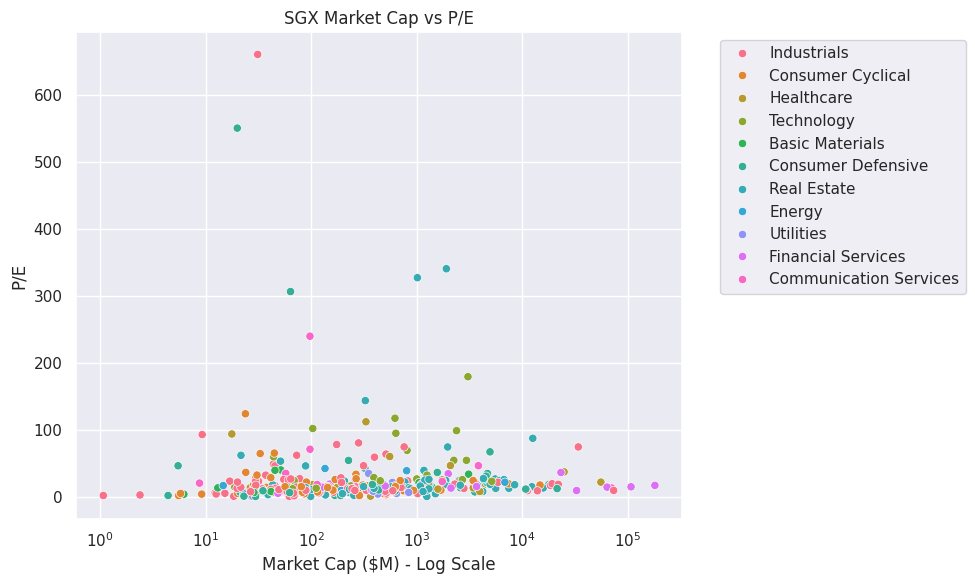

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 文字列（"SGD 250.843"など）から数値だけを抽出してfloat型に変換
# (すでに数値になっている場合はそのまま、欠損値はNaNになります)
if 'Mkt Cap ($M)' in df.columns:
    df['Mkt Cap_clean'] = df['Mkt Cap ($M)'].astype(str).str.replace(r'[^\d\.\-]', '', regex=True)
    df['Mkt Cap_clean'] = pd.to_numeric(df['Mkt Cap_clean'], errors='coerce')

# P/E列も数値型にキャスト
if 'P/E' in df.columns:
    df['P/E_clean'] = pd.to_numeric(df['P/E'], errors='coerce')

# 簡単な散布図プロット (時価総額 vs P/E)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Mkt Cap_clean', y='P/E_clean', hue='Sector')
plt.xscale('log') # 時価総額の桁数が違うためログスケールが見やすいです
plt.title('SGX Market Cap vs P/E')
plt.xlabel('Market Cap ($M) - Log Scale')
plt.ylabel('P/E')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()